# Predição do preço do ouro com GRU

Notebook do experimento GRU usando `data/processed/gold_features.csv`.

Mantém o mesmo setup lógico do experimento CNN:
- janelas de 60 dias
- horizontes de 5, 15 e 30 dias
- alvo em log-retorno acumulado
- métricas em preço reconstruído
- plots no mesmo estilo

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model, callbacks, layers


from src import (
    fit_and_scale,
    inverse_predict,
    per_year_metrics,
    plot_learning_curves,
    plot_predicted_vs_actual,
    plot_price_series,
    plot_return_predictions,
    plot_residuals,
    plot_scatter,
    plot_split_regions,
    plot_yearly_perf,
    regression_metrics,
    temporal_split,
)

from src import ROOT_DIR
REPO_ROOT = ROOT_DIR
SEED = 42
LOOKBACK = 60
HORIZONS = [5, 15, 30]
GAP = max(HORIZONS)
EPOCHS = 120
BATCH_SIZE = 64
CSV_PATH = REPO_ROOT / "data" / "processed" / "gold_features.csv"

np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10}
)

print("TensorFlow", tf.__version__)
print("Repo root:", REPO_ROOT)

I0000 00:00:1782143813.946459  132661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782143813.994582  132661 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782143815.071376  132661 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0
Repo root: /home/jose_edsouza/Documentos/Faculdade/Mestrado/ML/Trabalhos/repo/gold-forecast


## Carregamento

In [2]:
def load_processed_data(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, sep=None, engine="python")
    df.columns = [c.strip().lower() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df = df.dropna(subset=["date", "close"]).sort_values("date").reset_index(drop=True)
    return df


def select_feature_cols(df: pd.DataFrame) -> list[str]:
    blocked = {"date", "close", "open", "high", "low"}
    return [
        col
        for col in df.columns
        if col not in blocked
        and not col.startswith("y_")
        and pd.api.types.is_numeric_dtype(df[col])
        and df[col].nunique(dropna=True) > 1
    ]


df = load_processed_data(CSV_PATH)
feature_cols = select_feature_cols(df)

print(f"{len(df)} linhas | {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"{len(feature_cols)} features")
print(feature_cols)
df.head()

6177 linhas | 2000-08-30 -> 2025-04-14
19 features
['volume', 'log_ret_1', 'log_ret_5', 'log_ret_21', 'vol_5', 'vol_21', 'vol_ratio', 'dist_ma20', 'dist_ma50', 'ma_cross', 'rsi', 'macd_hist', 'boll_b', 'drawdown_252', 'hl_range', 'close_pos', 'gap_open', 'fear_ratio', 'fear_ma5']


,date,close,volume,log_ret_1,log_ret_5,log_ret_21,vol_5,vol_21,vol_ratio,dist_ma20,...,boll_b,drawdown_252,hl_range,close_pos,gap_open,fear_ratio,fear_ma5,y_5,y_15,y_30
0,2000-08-30,273.9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,NaN,0.000000,NaN,0.000365,-0.013231,0.009086
1,2000-08-31,278.3,0,0.015937,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.012576,0.5,0.003280,0.000000,NaN,-0.018130,-0.023633,-0.021428
2,2000-09-01,277.0,0,-0.004682,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.004682,0.062500,NaN,-0.014179,-0.010525,-0.020055
3,2000-09-05,275.8,2,-0.004342,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.004342,0.111111,NaN,-0.010571,-0.006913,-0.017188
4,2000-09-06,274.2,0,-0.005818,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,-0.5,-0.005818,0.142857,0.063294,-0.005119,0.015201,-0.014325


## Série histórica

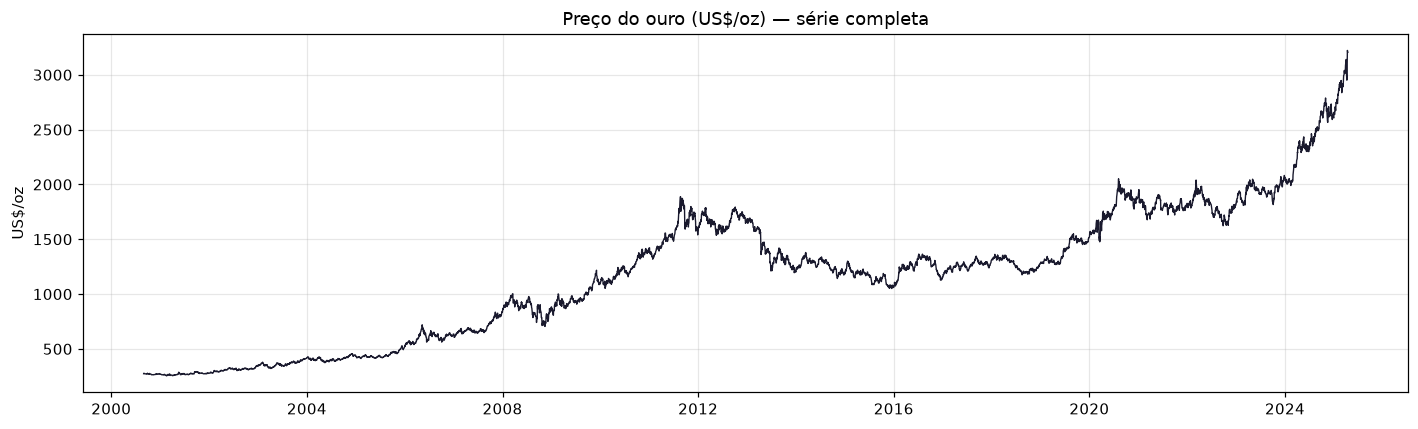

In [3]:
fig = plot_price_series(
    df["date"],
    df["close"],
    title="Preço do ouro (US$/oz) — série completa",
    ylabel="US$/oz",
)
plt.show()

## Exploração das features

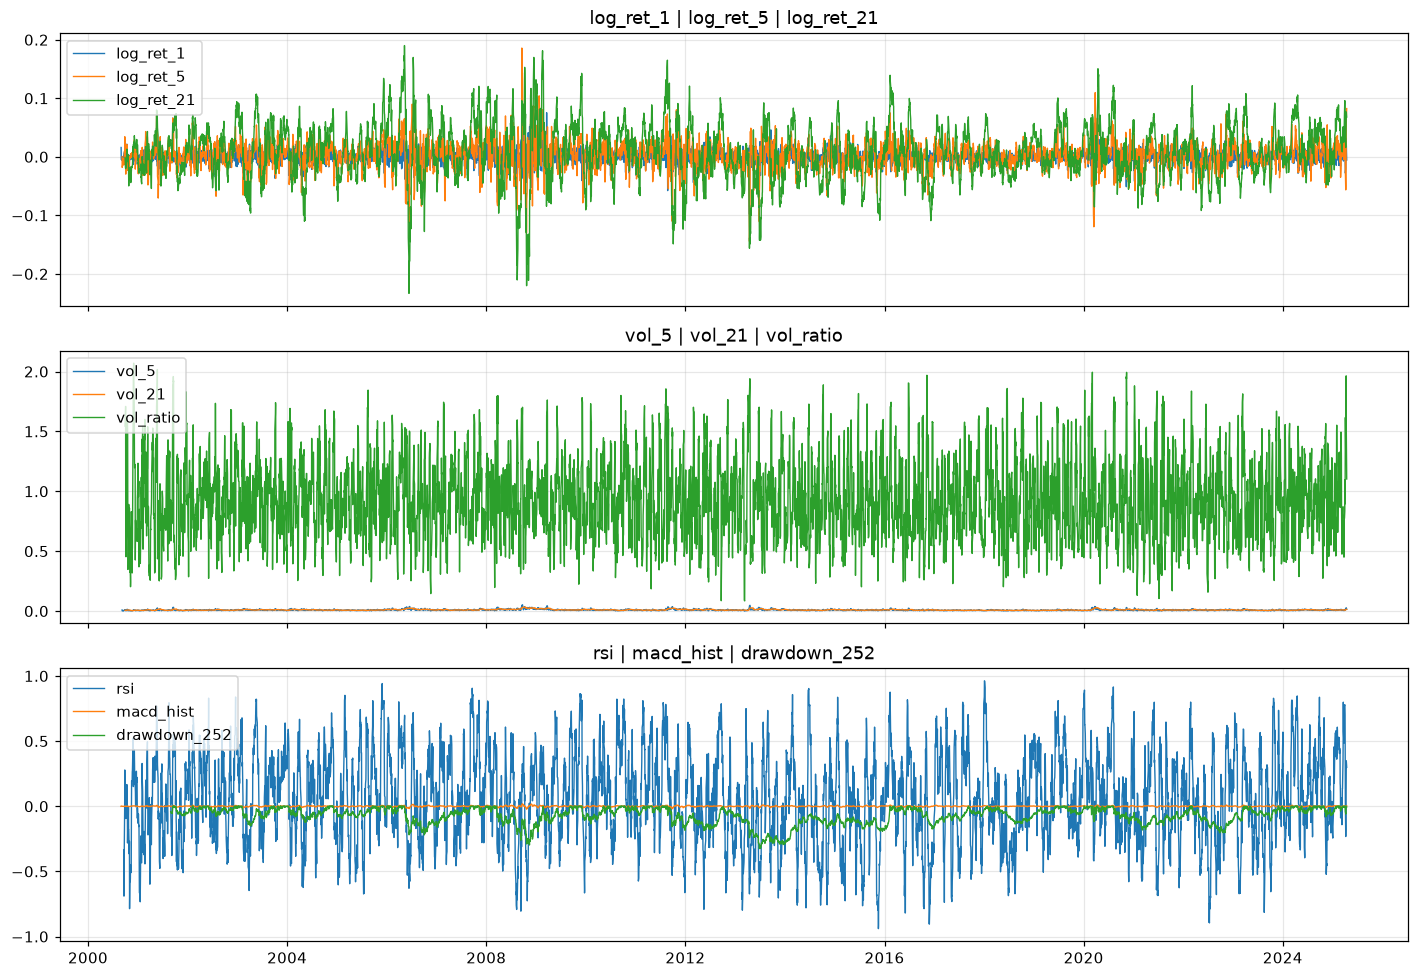

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
feature_sets = [
    ["log_ret_1", "log_ret_5", "log_ret_21"],
    ["vol_5", "vol_21", "vol_ratio"],
    ["rsi", "macd_hist", "drawdown_252"],
]
for ax, cols in zip(axes, feature_sets):
    for col in cols:
        if col in df.columns:
            ax.plot(df["date"], df[col], lw=0.9, label=col)
    ax.legend(loc="upper left")
    ax.set_title(" | ".join(cols))
plt.tight_layout()
plt.show()

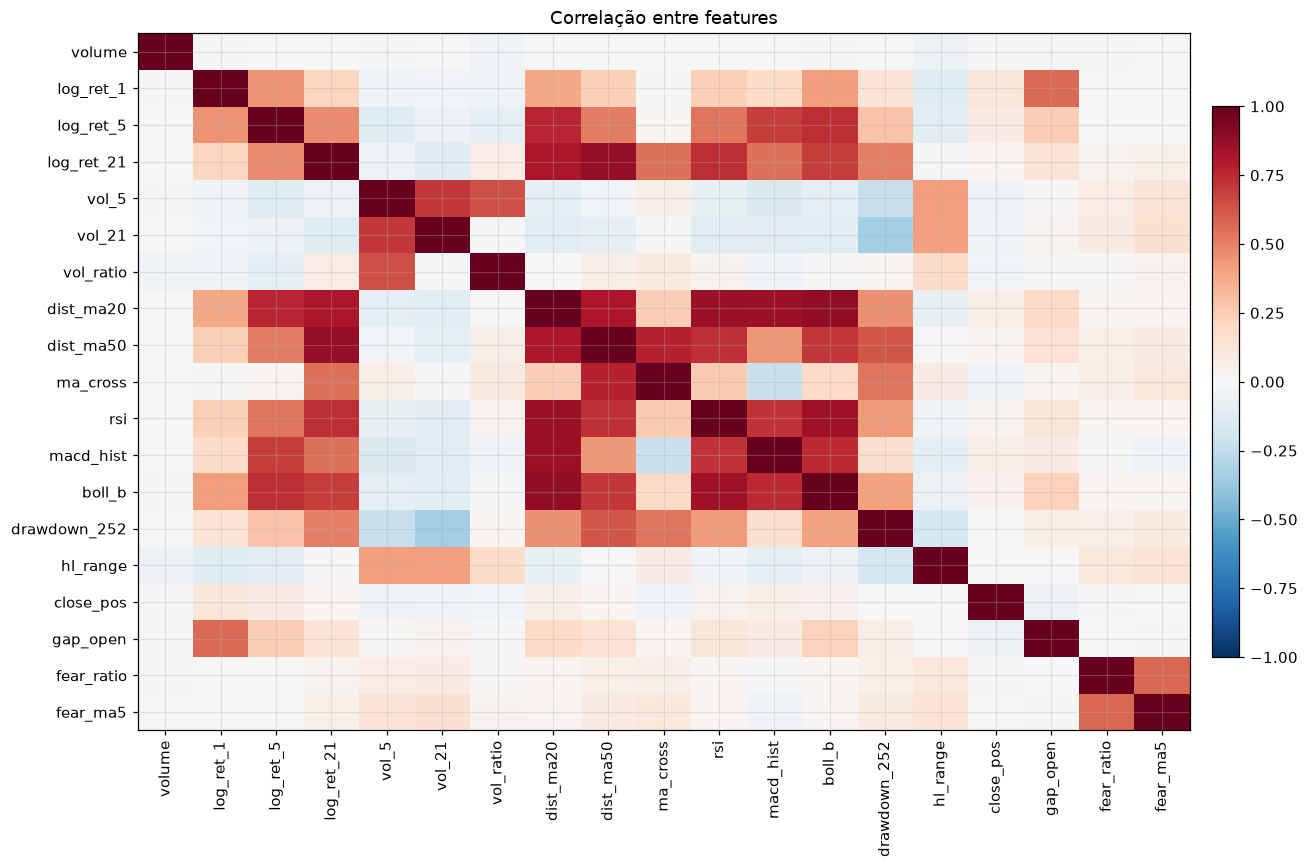

In [5]:
fig, ax = plt.subplots(figsize=(12, 8))
corr = df[feature_cols].corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feature_cols)
ax.set_title("Correlação entre features")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

## Split temporal e janelas

In [6]:
splits = temporal_split(
    df=df,
    feature_cols=feature_cols,
    horizons=HORIZONS,
    lookback=LOOKBACK,
    gap=GAP,
)

for name, ws in splits.items():
    d0 = df["date"].iloc[ws.idx[0]].date()
    d1 = df["date"].iloc[ws.idx[-1]].date()
    print(f"{name:>6}: {ws.X.shape} | {d0} -> {d1}")

treino: (4013, 60, 19) | 2001-11-29 -> 2017-11-27
   val: (837, 60, 19) | 2018-04-11 -> 2021-08-05
 teste: (807, 60, 19) | 2021-12-14 -> 2025-03-03


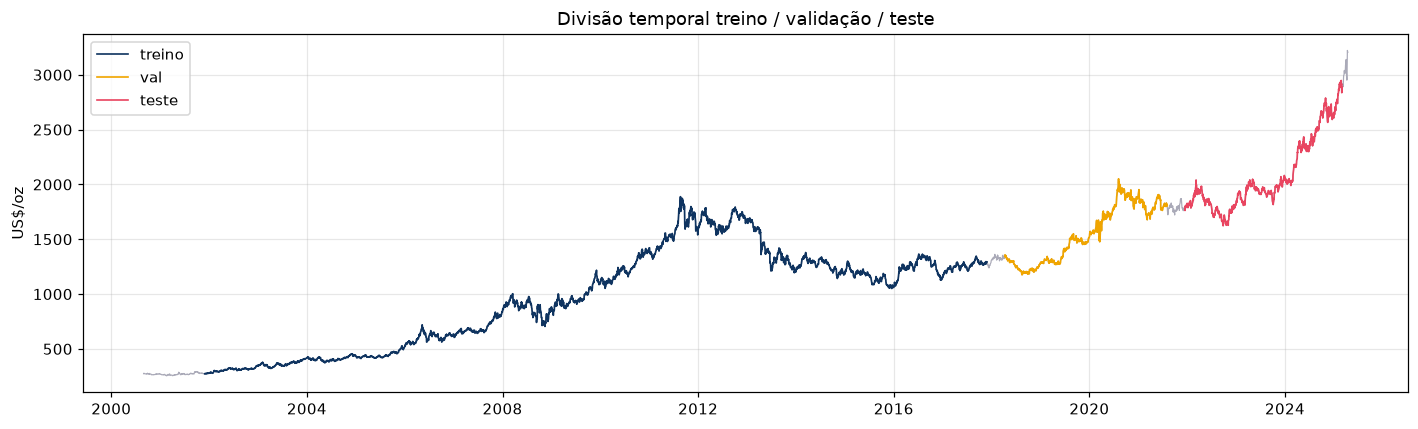

In [7]:
fig = plot_split_regions(
    df,
    {name: (ws.X, ws.Y, ws.prices, ws.idx) for name, ws in splits.items()},
    title="Divisão temporal treino / validação / teste",
    ylabel="US$/oz",
)
plt.show()

## Escalonamento

In [8]:
scaled = fit_and_scale(splits, horizons=HORIZONS, train_key="treino")
print("escala aplicada — treino X:", scaled.X["treino"].shape)

escala aplicada — treino X: (4013, 60, 19)


## Modelo GRU

In [9]:
# Hiperparâmetros obtidos via BayesianOptimization (outputs/03_gru/best_hp.json)
BEST_HP = {
    "units": 64,
    "spatial_dropout": 0.15,
    "dense_units": 96,
    "dropout": 0.30,
    "lr": 0.0001395510628578222,
    "loss_weight_h15": 0.4,
    "loss_weight_h30": 0.2,
}


def build_model(n_features: int) -> Model:
    inp = layers.Input(shape=(LOOKBACK, n_features))
    x = layers.GRU(BEST_HP["units"], return_sequences=True)(inp)
    x = layers.LayerNormalization()(x)
    x = layers.SpatialDropout1D(BEST_HP["spatial_dropout"])(x)
    x = layers.GRU(BEST_HP["units"])(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dense(BEST_HP["dense_units"], activation="relu")(x)
    x = layers.Dropout(BEST_HP["dropout"])(x)
    outs = [layers.Dense(1, name=f"h{h}")(x) for h in HORIZONS]
    model = Model(inp, outs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(BEST_HP["lr"]),
        loss={f"h{h}": tf.keras.losses.Huber(1.0) for h in HORIZONS},
        loss_weights={
            "h5": 1.0,
            "h15": BEST_HP["loss_weight_h15"],
            "h30": BEST_HP["loss_weight_h30"],
        },
    )
    return model


model = build_model(len(feature_cols))
model.summary()

W0000 00:00:1782143819.156362  132985 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782143819.194551  132661 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 19)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 60, 64)    │     16,320 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 64)    │        128 │ gru[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 60, 64)    │          0 │ layer_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 64)        │     24,960 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ gru_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │      6,240 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h5 (Dense)          │ (None, 1)         │         97 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h15 (Dense)         │ (None, 1)         │         97 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h30 (Dense)         │ (None, 1)         │         97 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 48,067 (187.76 KB)

 Trainable params: 48,067 (187.76 KB)

 Non-trainable params: 0 (0.00 B)

## Treino

In [10]:
history = model.fit(
    scaled.X["treino"],
    scaled.Y_dict("treino"),
    validation_data=(scaled.X["val"], scaled.Y_dict("val")),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0,
    callbacks=[
        callbacks.EarlyStopping(
            monitor="val_loss", patience=15, restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5
        ),
    ],
)
print(f"Treinou {len(history.history['loss'])} épocas")

Treinou 33 épocas


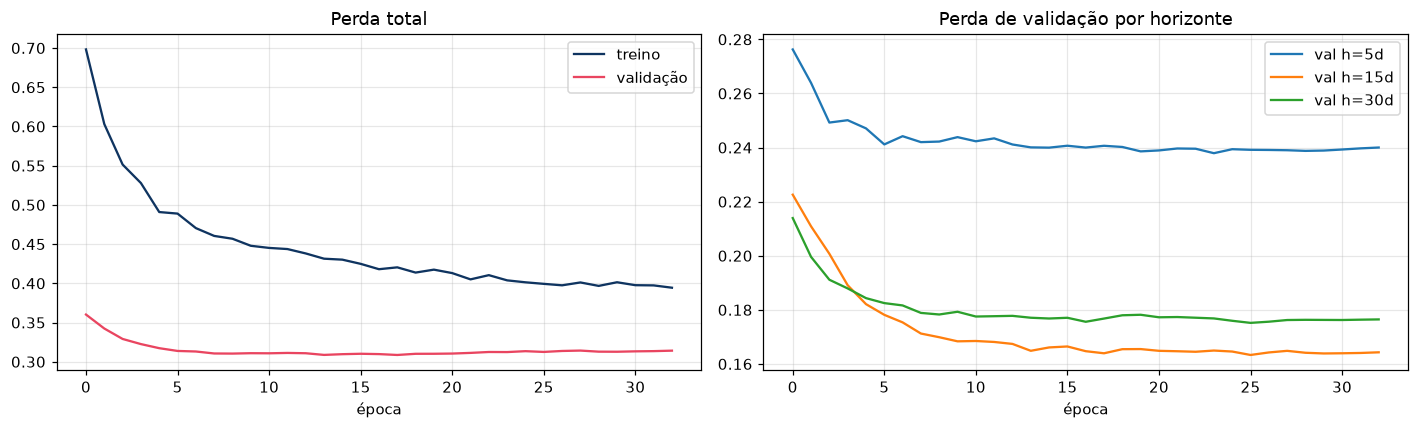

In [11]:
fig = plot_learning_curves(history.history, HORIZONS)
plt.show()

## Avaliação

In [12]:
def predict_returns(X: np.ndarray) -> np.ndarray:
    return inverse_predict(model.predict(X, verbose=0), scaled.y_scaler).astype(
        np.float32
    )


preds = {
    split: predict_returns(scaled.X[split]) for split in ["treino", "val", "teste"]
}

tbl = pd.concat(
    [
        regression_metrics(
            scaled.Yreal[split],
            preds[split],
            scaled.prices[split],
            HORIZONS,
            split_name=split,
        )
        for split in ["treino", "val", "teste"]
    ],
    ignore_index=True,
)
tbl.round(3)

,split,h,MAE,RMSE,MAPE%,DirAcc%,MAE/naive
0,treino,5,17.279,25.517,1.775,63.967,0.917
1,treino,15,29.640,42.331,3.004,66.459,0.902
2,treino,30,42.162,59.885,4.267,63.768,0.936
3,val,5,24.413,35.853,1.522,51.971,0.992
4,val,15,40.902,55.109,2.557,51.374,1.010
5,val,30,59.374,74.005,3.720,53.524,1.011
6,teste,5,32.597,41.585,1.567,53.284,0.989
7,teste,15,59.385,74.561,2.821,54.399,0.993
8,teste,30,82.924,101.562,3.879,63.445,0.948


In [13]:
t = tbl[tbl["split"] == "teste"].set_index("h")[
    ["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]
]
print("DESEMPENHO NO TESTE")
print(t.round(2).to_string())
print("\nMAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção")

DESEMPENHO NO TESTE
      MAE    RMSE  MAPE%  DirAcc%  MAE/naive
h                                           
5   32.60   41.59   1.57    53.28       0.99
15  59.38   74.56   2.82    54.40       0.99
30  82.92  101.56   3.88    63.44       0.95

MAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção


## Plots de desempenho

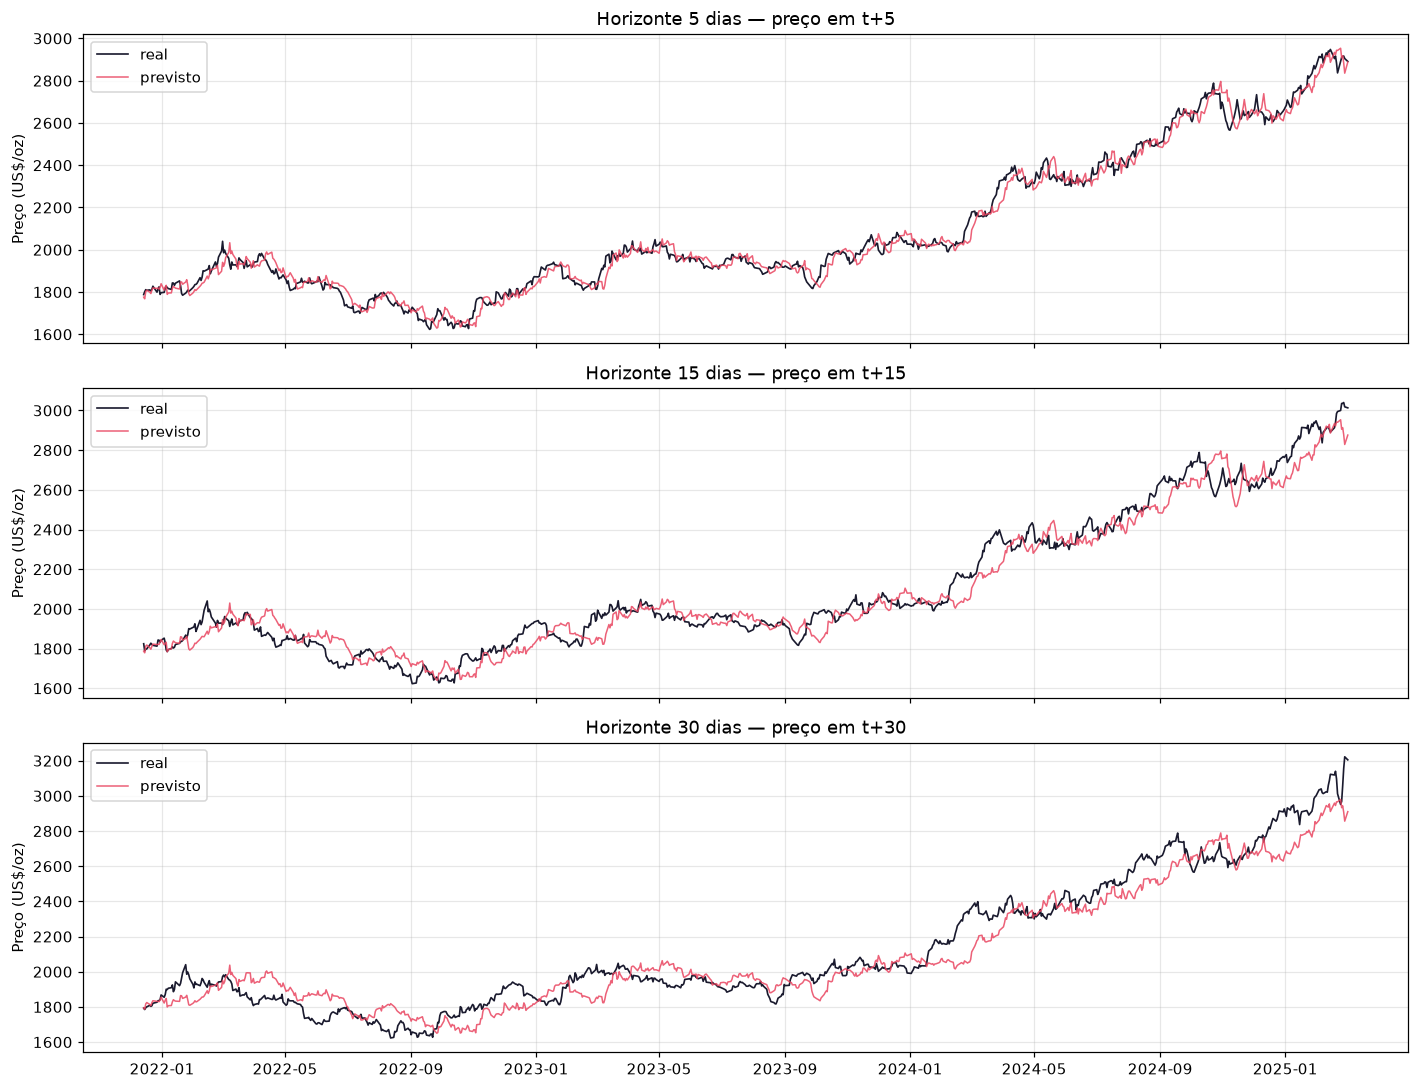

In [14]:
dates_te = df["date"].values[scaled.idx["teste"]]
fig = plot_predicted_vs_actual(
    dates_te,
    scaled.Yreal["teste"],
    preds["teste"],
    scaled.prices["teste"],
    HORIZONS,
    ylabel="Preço (US$/oz)",
)
plt.show()

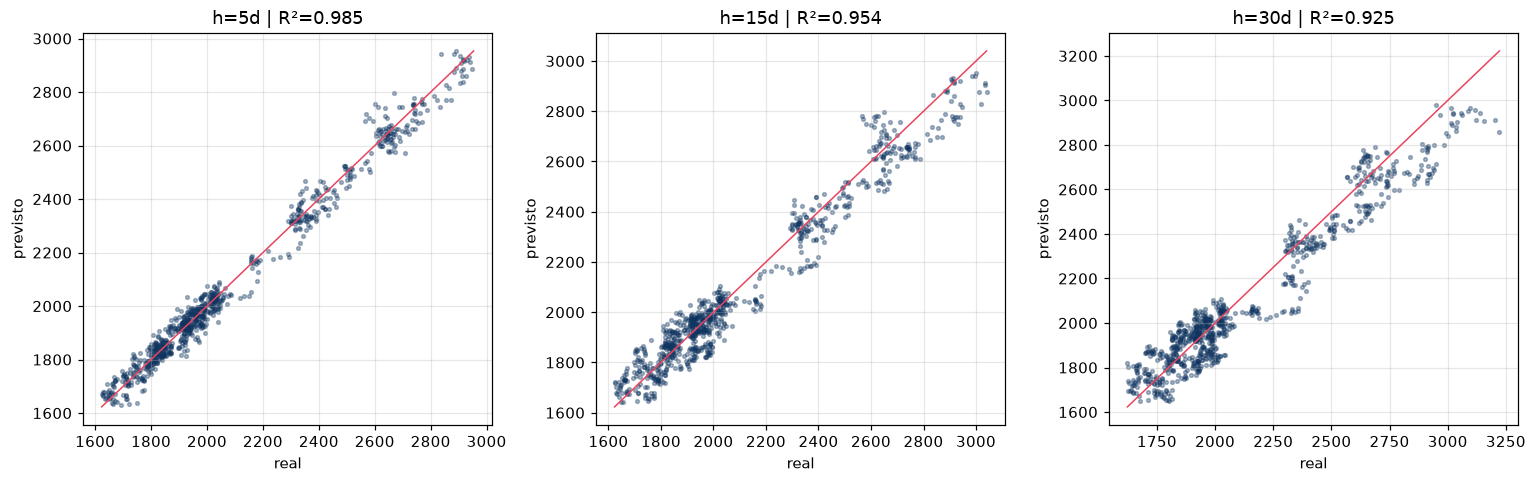

In [15]:
fig = plot_scatter(
    scaled.Yreal["teste"],
    preds["teste"],
    scaled.prices["teste"],
    HORIZONS,
)
plt.show()

In [16]:
h30_idx = HORIZONS.index(30)
yearly = per_year_metrics(
    scaled.Yreal["teste"],
    preds["teste"],
    scaled.prices["teste"],
    dates_te,
    horizon_idx=h30_idx,
)
yearly

,DirAcc%,MAE/naive
ano,,
2021,84.615385,0.503389
2022,48.605578,1.038002
2023,54.400000,1.018776
2024,80.158730,0.876215
2025,100.000000,0.850814


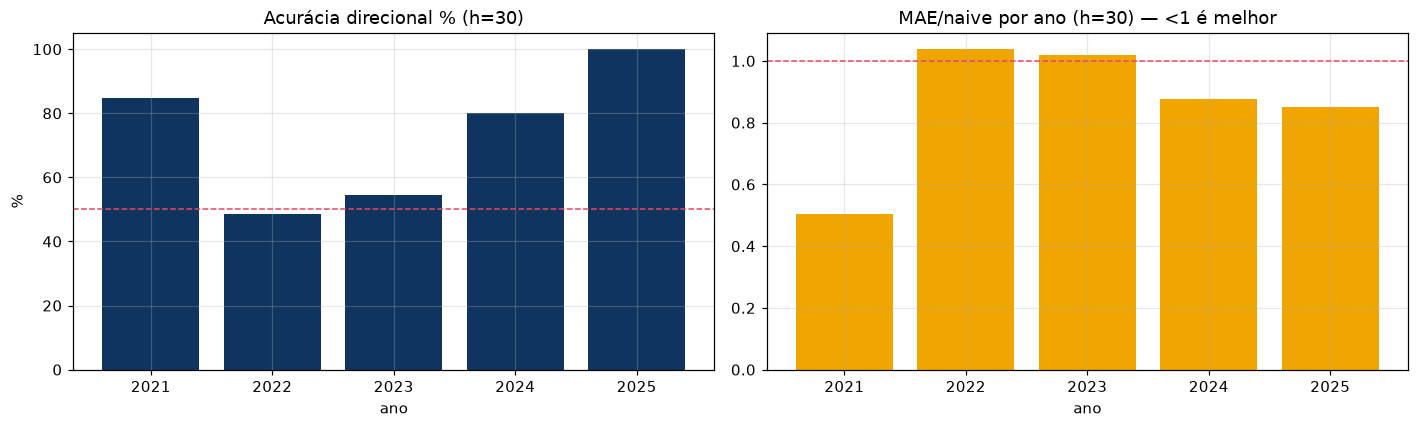

In [17]:
fig = plot_yearly_perf(yearly, horizon=30)
plt.show()

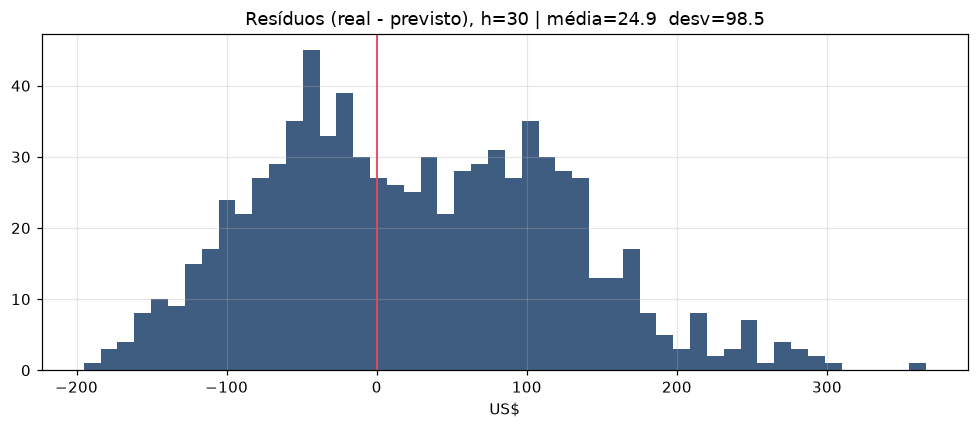

In [18]:
fig = plot_residuals(
    scaled.Yreal["teste"],
    preds["teste"],
    scaled.prices["teste"],
    horizon_idx=h30_idx,
    horizon=30,
)
plt.show()

## Diagnósticos extras

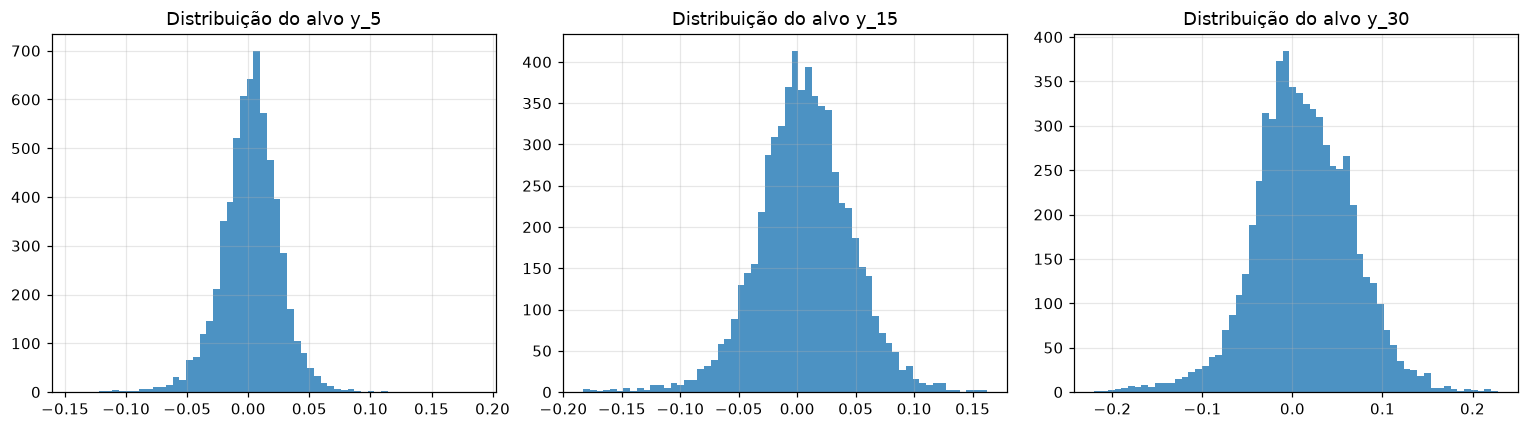

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, h in zip(axes, HORIZONS):
    col = f"y_{h}"
    ax.hist(df[col].dropna(), bins=60, alpha=0.8)
    ax.set_title(f"Distribuição do alvo {col}")
plt.tight_layout()
plt.show()

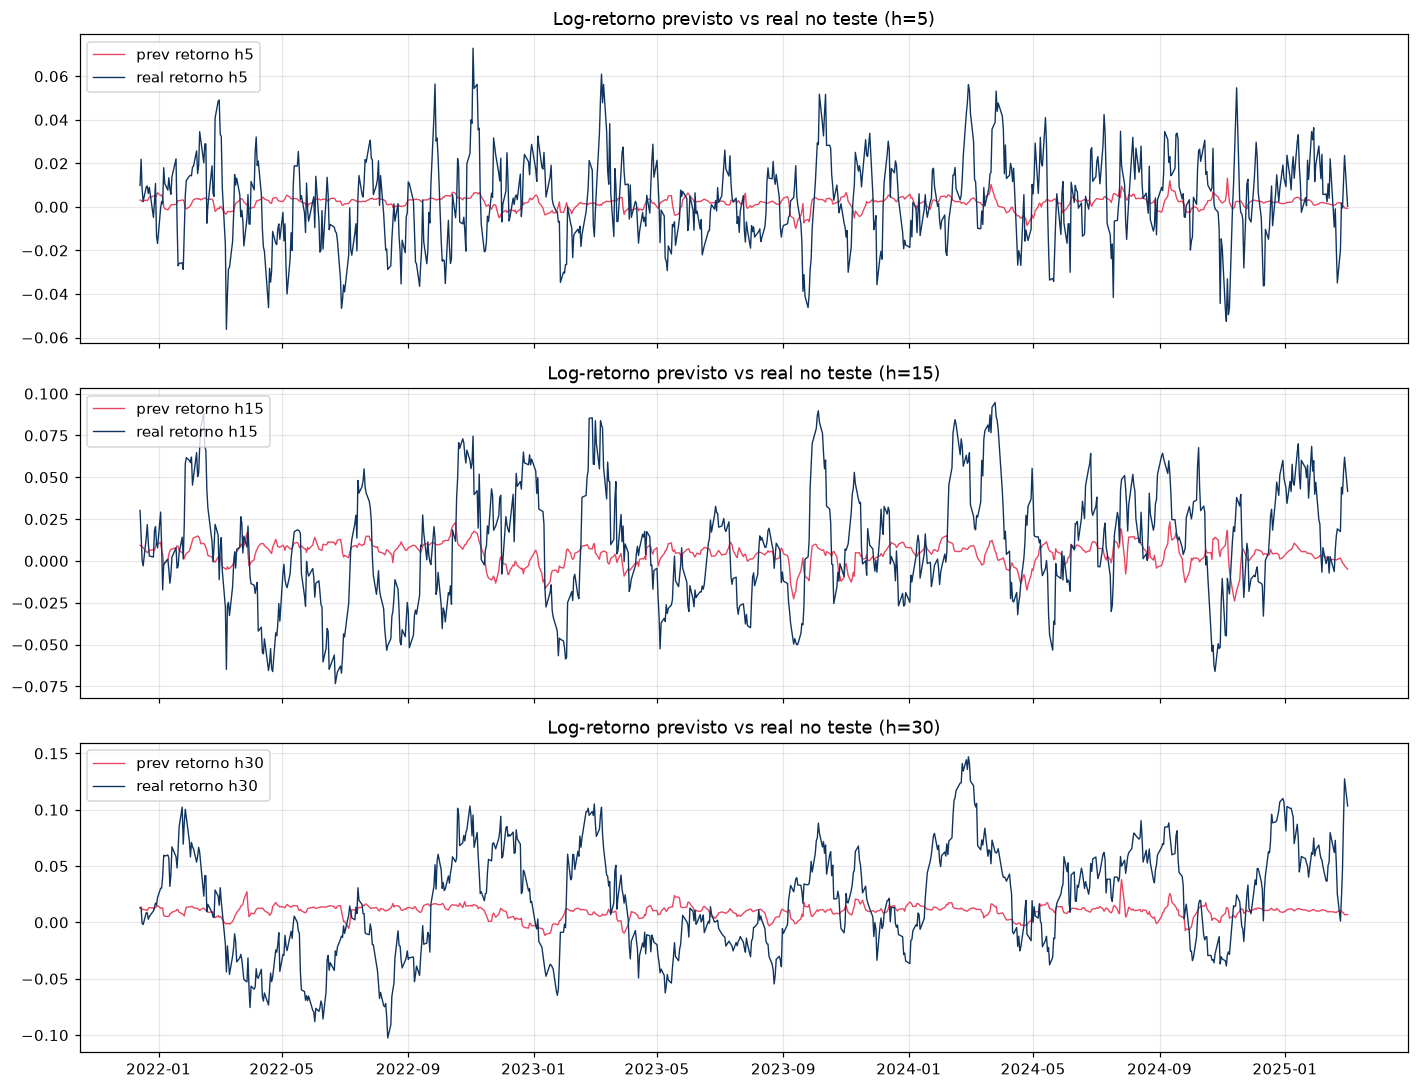

In [20]:
fig = plot_return_predictions(
    dates_te,
    scaled.Yreal["teste"],
    preds["teste"],
    HORIZONS,
)
plt.show()